<a href="https://colab.research.google.com/github/Muhammad-AHMAD07/ML_Lab/blob/main/ML(Lab_5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries Import

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Preprocessing and Loading

In [ ]:
# Read dataset
dataset =pd.read_csv('/content/sample_data/california_housing_test.csv')


In [ ]:
# Display first 5 rows
dataset.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


In [ ]:
dataset.nunique()

,0
longitude,607
latitude,587
housing_median_age,52
total_rooms,2215
total_bedrooms,1055
population,1802
households,1026
median_income,2578
median_house_value,1784


Selecting Feature

In [ ]:
cols_to_use = ['longitude','latitude','housing_median_age','total_rooms','total_bedrooms','median_house_value']
dataset= dataset[cols_to_use]

In [ ]:
dataset.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population
0,-122.05,37.37,27.0,3885.0,661.0,1537.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0
3,-118.36,33.82,28.0,67.0,15.0,49.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0


In [ ]:
dataset.shape

(3000, 6)

In [ ]:
dataset.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0


Handling missing values

In [ ]:
# Some feature's missing values can be treated as zero (another class
#for NA values or absence of that feature)
# like 0 for Propertycount, Bedroom2 will refer to other class of NA
#values
# like 0 for Car feature will mean that there's no car parking feature
#with house cols_to_fill_zero = ['Propertycount', 'Distance',
#'Bedroom2',
#'Bathroom', 'Car'] dataset[cols_to_fill_zero] =
#dataset[cols_to_fill_zero].fillna(0)
# other continuous features can be imputed with mean for faster results
#since our focus is on Reducing overfitting # using Lasso and Ridge
#Regression dataset['Landsize'] =
#dataset['Landsize'].fillna(dataset.Landsize.mean())
#dataset['BuildingArea'] =
#dataset['BuildingArea'].fillna(dataset.BuildingArea.mean())
#dataset.dropna(inplace=True)
#dataset.shape

Encoding

In [ ]:
dataset = pd.get_dummies(dataset, drop_first=True)

In [ ]:
dataset.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population
0,-122.05,37.37,27.0,3885.0,661.0,1537.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0
3,-118.36,33.82,28.0,67.0,15.0,49.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0


bifircation of test and train

In [ ]:
X = dataset.drop('population', axis=1)
y= dataset['population']

In [ ]:
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y,test_size=0.3, random_state=42)

Linear Regresssion Model

In [ ]:
from sklearn.linear_model import LinearRegression
reg =LinearRegression().fit(train_X, train_y)
reg.score(test_X,test_y)
reg.score(train_X,train_y)

0.74462875995089

L2 Regularization

In [ ]:
from sklearn.linear_model import Ridge
ridge_reg=Ridge(alpha=50, max_iter=100, tol=0.1)
ridge_reg.fit(train_X, train_y)
ridge_reg.score(test_X,test_y)
ridge_reg.score(train_X, train_y)

0.7446222603566297

L1 Regularization

In [ ]:
from sklearn import linear_model
lasso_reg =linear_model.Lasso(alpha=50, max_iter=100, tol=0.1)
lasso_reg.fit(train_X, train_y)
lasso_reg.score(test_X,test_y)
lasso_reg.score(train_X,train_y)

0.7435497334569381

Visulization

In [ ]:
# Import necessary libraries
from sklearn.linear_model import Ridge, Lasso
# Train Ridge Regression (L2)
ridge_reg =Ridge(alpha=50, max_iter=100, tol=0.1)
ridge_reg.fit(train_X, train_y)
# Train Lasso Regression (L1)
lasso_reg =Lasso(alpha=50, max_iter=100, tol=0.1)
lasso_reg.fit(train_X, train_y)
# Store R² scores
lin_train_score =reg.score(train_X, train_y)
lin_test_score =reg.score(test_X, test_y)
ridge_train_score = ridge_reg.score(train_X,train_y)
ridge_test_score = ridge_reg.score(test_X,test_y)
lasso_train_score = lasso_reg.score(train_X,train_y)
lasso_test_score = lasso_reg.score(test_X,test_y)
# Create a dataframe for visualization
import pandas as pd
score_df =pd.DataFrame({
 "Model": ["Linear Regression", "Ridge", "Lasso"],
"Train Score": [lin_train_score, ridge_train_score,
lasso_train_score],
 "Test Score": [lin_test_score, ridge_test_score, lasso_test_score]
})

Linear Regression -Train Score: 0.7446
Linear Regression -Test Score: 0.7575

Ridge Regression - Train Score:0.7446
Ridge Regression - Test Score:0.7576

Lasso Regression - Train Score:0.7435
Lasso Regression - Test Score:0.7574


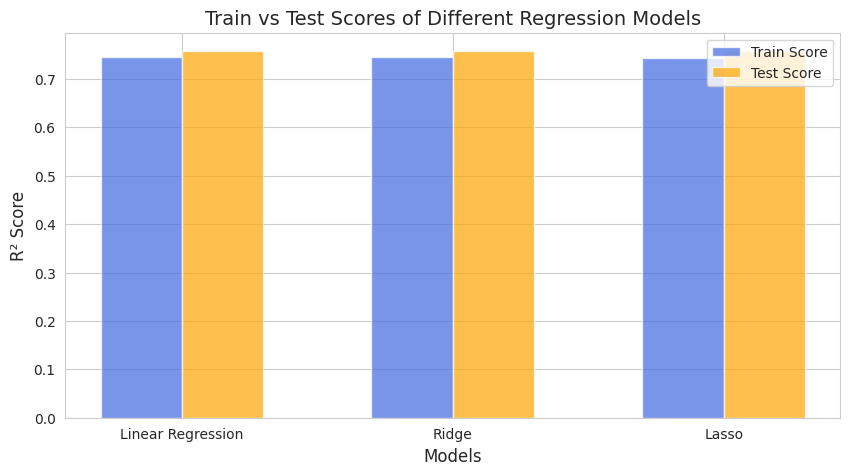

In [ ]:
# Print the R² scores for each model
print(f"Linear Regression -Train Score: {lin_train_score:.4f}")
print(f"Linear Regression -Test Score: {lin_test_score:.4f}\n")
print(f"Ridge Regression - Train Score:{ridge_train_score:.4f}")
print(f"Ridge Regression - Test Score:{ridge_test_score:.4f}\n")
print(f"Lasso Regression - Train Score:{lasso_train_score:.4f}")
print(f"Lasso Regression - Test Score:{lasso_test_score:.4f}")
import matplotlib.pyplot as plt
import seaborn as sns
# Set the style for plots
sns.set_style("whitegrid")
# Plot Train vs Test scores for different models
plt.figure(figsize=(10, 5))
# Bar plot for Train and Test scores
X_axis = ["Linear Regression", "Ridge", "Lasso"]
train_scores =[lin_train_score, ridge_train_score, lasso_train_score]
test_scores =[lin_test_score, ridge_test_score, lasso_test_score]
bar_width = 0.3 # Bar width for better visibility
index = range(len(X_axis))
plt.bar(index, train_scores, width=bar_width, label="Train Score",color='royalblue', alpha=0.7)
plt.bar([i + bar_width for i in index],test_scores, width=bar_width, label="Test Score", color='orange',alpha=0.7)
# Labels and title
plt.xlabel("Models", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.title("Train vs Test Scores of Different Regression Models", fontsize=14)
plt.xticks([i + bar_width / 2 for i in index], X_axis)
plt.legend()
plt.show()